## 330 - Making a Stüve Plot

[Youtube](https://www.youtube.com/watch?v=fP5R7Rgqs9k)

In [1]:
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
import numpy as np

from datetime import datetime
from metpy.plots import Stuve
from metpy.units import units, pandas_dataframe_to_unit_arrays
from siphon.simplewebservice.wyoming import WyomingUpperAir

In [2]:
date = datetime(2013, 5, 20, 18)
station = 'OUN'

In [3]:
df = WyomingUpperAir.request_data(date, station)
df.head()


,pressure,height,temperature,dewpoint,direction,speed,u_wind,v_wind,station,station_number,time,latitude,longitude,elevation,pw
0,966.0,345,27.4,22.4,185.0,10.0,0.871557,9.961947,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
1,958.0,419,26.2,21.3,185.0,12.0,1.045869,11.954336,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
2,937.6,610,24.1,19.6,185.0,16.0,1.394492,15.939115,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
3,925.0,730,22.8,18.6,185.0,16.0,1.394492,15.939115,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76
4,914.0,834,21.6,17.9,193.0,18.0,4.049119,17.538661,OUN,72357,2013-05-20 18:00:00,35.18,-97.44,345.0,32.76


In [4]:
df = pandas_dataframe_to_unit_arrays(df)

In [5]:
df

{'pressure': <Quantity([966.  958.  937.6 925.  914.  905.6 876.  874.3 850.  844.  835.  825.
  820.  814.  813.  794.  789.  785.4 781.  757.6 730.6 700.  653.5 606.
  586.  561.1 539.6 524.  503.  500.  492.  479.  400.  390.6 343.8 342.
  326.  315.  302.  300.  278.  250.  238.  224.  219.  218.2 211.  202.
  200.  199.  191.  187.  173.  159.  152.  150.  149.3 137.  134.  129.1
  129.  122.8 121.  119.  118.  116.9 107.  100.   88.4  84.6  81.2  79.8
   74.5  70.   67.4  63.6  61.   59.2  58.   56.4  55.3  52.6  50.1  50.
   49.7  48.2  45.5  43.9  43.3  39.5  39.3  37.5  32.5  31.   30.9  30.
   29.5  29.4  28.1  25.6  24.4  22.5  22.2  21.1  20.2  20.   19.2  18.6
   17.5  16.7  14.   13.   11.9  11.1  10.9  10.6  10.2], 'hectopascal')>,
 'height': <Quantity([  345   419   610   730   834   914  1202  1219  1461  1522  1613  1715
   1767  1829  1840  2041  2095  2134  2182  2438  2743  3103  3658  4267
   4538  4877  5182  5410  5724  5770  5894  6096  7450  7620  8534  8572
 

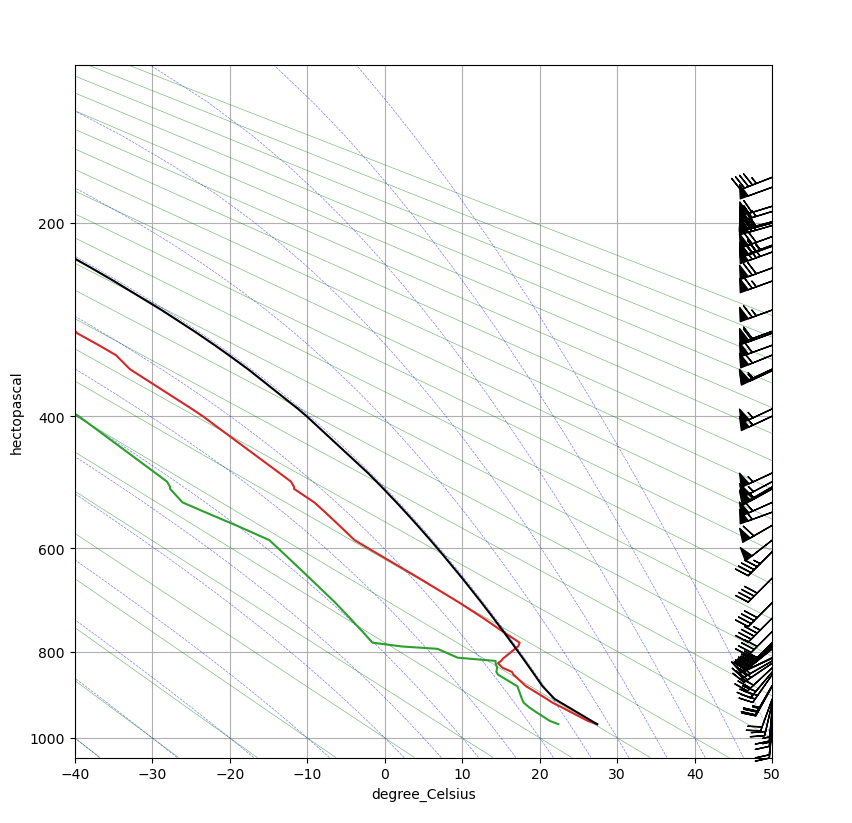

In [6]:
fig = plt.figure(figsize=(9, 9))

stuve = Stuve(fig)

stuve.plot(df['pressure'], df['temperature'], 'tab:red')
stuve.plot(df['pressure'], df['dewpoint'], 'tab:green')

wind_pressure, wind_u, wind_v = mpcalc.get_layer(df['pressure'], df['u_wind'], df['v_wind'], depth=800 * units.hPa)
stuve.plot_barbs(wind_pressure, wind_u, wind_v)

# Calculate parcel profile and plot
prof = mpcalc.parcel_profile(df['pressure'], df['temperature'][0], df['dewpoint'][0]).to('degC')
stuve.plot(df['pressure'], prof, 'k')

# Fiducial Lines
stuve.plot_dry_adiabats(colors='green', linestyle='-', linewidth=0.5, t0=np.arange(-40, 200, 10)*units.degC)
stuve.plot_moist_adiabats(linewidth=0.5)